# NLP-based Game Recommendation Using Steam User Review

# Stage 1: Read the data and confirm the structure

In [1]:
import os
import pandas as pd
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))
FILE_PATH = "/kaggle/input/datasets/lijinmarcus/steam-players-review/dataset.csv"

# Only load required columns
use_cols = ["app_id", "app_name", "review_text", "review_score", "review_votes"]

df = pd.read_csv(FILE_PATH, usecols=use_cols, low_memory=False)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

/kaggle/input/datasets/lijinmarcus/steam-players-review/dataset.csv
Dataset shape: (6417106, 5)

Columns:
['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']

First 5 rows:


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1


# Stage 2: Clean the dataset and create the target label

In [2]:
import re

# Remove rows with missing values in key columns
df = df.dropna(subset=["app_name", "review_text", "review_score"]).copy()

# Keep only valid review scores
df = df[df["review_score"].isin([1, -1])].copy()

# Map labels: 1 -> positive, -1 -> negative
df["target"] = df["review_score"].map({1: 1, -1: 0})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review_text"].apply(clean_text)

# Remove empty cleaned text
df = df[df["clean_review"].str.len() > 0].copy()

print("Cleaned dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["target"].value_counts())

display(df[["app_name", "review_text", "clean_review", "target"]].head())

Cleaned dataset shape: (6202513, 7)

Target distribution:
target
1    5106431
0    1096082
Name: count, dtype: int64


,app_name,review_text,clean_review,target
0,Counter-Strike,Ruined my life.,ruined my life,1
1,Counter-Strike,This will be more of a ''my experience with th...,this will be more of a my experience with this...,1
2,Counter-Strike,This game saved my virginity.,this game saved my virginity,1
3,Counter-Strike,• Do you like original games? • Do you like ga...,do you like original games do you like games t...,1
4,Counter-Strike,"Easy to learn, hard to master.",easy to learn hard to master,1


# Stage 3: Sample a smaller dataset

In [3]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 100000
RANDOM_STATE = 42

if len(df) > SAMPLE_SIZE:
    df_sample, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        stratify=df["target"],
        random_state=RANDOM_STATE
    )
    df = df_sample.copy()

print("Sampled dataset shape:", df.shape)
print("\nSampled target distribution:")
print(df["target"].value_counts())

Sampled dataset shape: (100000, 7)

Sampled target distribution:
target
1    82328
0    17672
Name: count, dtype: int64


# Stage 4: Split the data into training and testing sets

In [4]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 80000
Test set size: 20000


# Stage 5: Train the Logistic Regression model

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=15000)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["Negative", "Positive"]))

Logistic Regression Accuracy: 0.8752

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.39      0.53      3534
    Positive       0.88      0.98      0.93     16466

    accuracy                           0.88     20000
   macro avg       0.84      0.69      0.73     20000
weighted avg       0.87      0.88      0.86     20000



# Stage 6: Train the Naive Bayes model

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=15000)),
    ("clf", MultinomialNB())
])

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("\nClassification Report:")
print(classification_report(y_test, nb_pred, target_names=["Negative", "Positive"]))

Naive Bayes Accuracy: 0.8482

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.17      0.28      3534
    Positive       0.85      0.99      0.92     16466

    accuracy                           0.85     20000
   macro avg       0.85      0.58      0.60     20000
weighted avg       0.85      0.85      0.80     20000



# Stage 7: Compare model performance

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_pred),
        "Precision": precision_score(y_test, lr_pred, zero_division=0),
        "Recall": recall_score(y_test, lr_pred, zero_division=0),
        "F1-score": f1_score(y_test, lr_pred, zero_division=0)
    },
    {
        "Model": "Naive Bayes",
        "Accuracy": accuracy_score(y_test, nb_pred),
        "Precision": precision_score(y_test, nb_pred, zero_division=0),
        "Recall": recall_score(y_test, nb_pred, zero_division=0),
        "F1-score": f1_score(y_test, nb_pred, zero_division=0)
    }
])

results = results.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

display(results)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8752,0.882698,0.978440,0.928106
1,Naive Bayes,0.8482,0.848000,0.993745,0.915105


# Stage 8: Plot confusion matrices

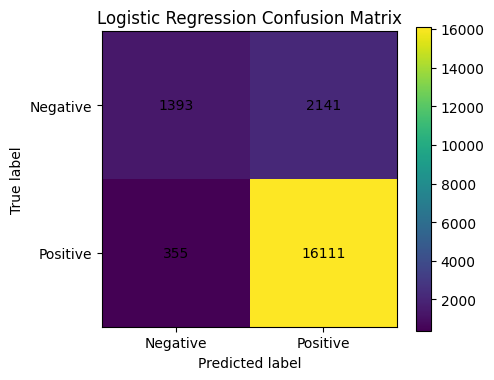

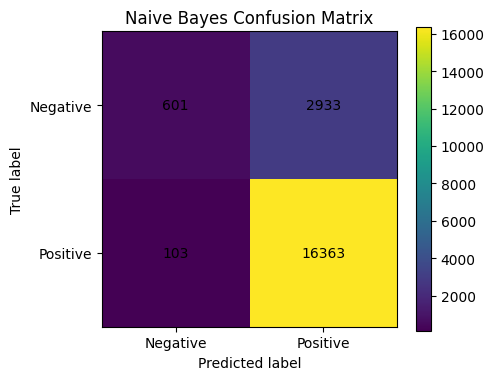

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Negative", "Positive"])
    plt.yticks(tick_marks, ["Negative", "Positive"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

lr_cm = confusion_matrix(y_test, lr_pred)
nb_cm = confusion_matrix(y_test, nb_pred)

plot_confusion_matrix(lr_cm, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(nb_cm, "Naive Bayes Confusion Matrix")

# Stage 9: Select the best model and predict all reviews

In [9]:
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Logistic Regression":
    best_model = lr_model
else:
    best_model = nb_model

print("Best model:", best_model_name)

df["predicted_sentiment"] = best_model.predict(df["clean_review"])
df["predicted_sentiment_label"] = df["predicted_sentiment"].map({1: "Positive", 0: "Negative"})

if hasattr(best_model.named_steps["clf"], "predict_proba"):
    df["positive_probability"] = best_model.predict_proba(df["clean_review"])[:, 1]
else:
    df["positive_probability"] = None

display(df[["app_name", "review_text", "target", "predicted_sentiment_label", "positive_probability"]].head())

Best model: Logistic Regression


,app_name,review_text,target,predicted_sentiment_label,positive_probability
6153186,Portal 2,Great game some of the tests are nice and hard...,1,Positive,0.968582
5035020,Ultimate Chicken Horse,Great!,1,Positive,0.999796
2880742,Stonehearth,Early Access Review,1,Positive,0.798433
5622939,Techwars Online,Cool!,1,Positive,0.981597
5332277,Super Meat Boy,Not a fan of rage paltformers. It's a very pol...,0,Positive,0.820872


# Stage 10: Build the game recommendation ranking

In [10]:
import numpy as np

# Group reviews by game
game_summary = (
    df.groupby("app_name")
    .agg(
        review_count=("predicted_sentiment", "count"),
        positive_ratio=("predicted_sentiment", "mean"),
        avg_positive_prob=("positive_probability", "mean"),
        total_votes=("review_votes", "sum")
    )
    .reset_index()
)

# Keep only games with enough reviews
# This reduces the chance that niche games with very few reviews dominate the ranking
MIN_REVIEWS = 200
game_summary = game_summary[game_summary["review_count"] >= MIN_REVIEWS].copy()

# Normalize review count into a 0-1 style weight using log scaling
# This avoids giving too much advantage to extremely large games
game_summary["review_count_weight"] = (
    np.log1p(game_summary["review_count"]) /
    np.log1p(game_summary["review_count"].max())
)

# Improved recommendation score
# positive_ratio: main sentiment signal
# avg_positive_prob: model confidence
# review_count_weight: robustness / reliability of the ranking
game_summary["recommendation_score"] = (
    game_summary["positive_ratio"] * 0.6 +
    game_summary["avg_positive_prob"] * 0.2 +
    game_summary["review_count_weight"] * 0.2
)

# Sort games by final recommendation score
game_summary = game_summary.sort_values(
    by=["recommendation_score", "review_count", "total_votes"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Top 15 recommended games:")
display(game_summary.head(15))

Top 15 recommended games:


,app_name,review_count,positive_ratio,avg_positive_prob,total_votes,review_count_weight,recommendation_score
0,Terraria,1357,0.983051,0.927627,137,0.994624,0.974281
1,Portal 2,645,0.990698,0.940140,36,0.892184,0.960883
2,DayZ,1405,1.000000,0.798433,223,0.999413,0.959569
3,Rust,1228,1.000000,0.798433,146,0.980862,0.955859
4,Undertale,827,0.969770,0.908850,108,0.926407,0.948914
5,FTL: Faster Than Light,407,0.987715,0.923813,14,0.828824,0.943157
6,Rocket League,858,0.960373,0.895485,121,0.931475,0.941616
7,The Binding of Isaac,313,0.993610,0.927371,22,0.792718,0.940184
8,Robocraft,687,1.000000,0.798433,117,0.900869,0.939860
9,Left 4 Dead 2,830,0.959036,0.888148,85,0.926906,0.938432


# Stage 11: Save the output files

In [11]:
results.to_csv("model_comparison_results.csv", index=False)
df.to_csv("review_level_predictions.csv", index=False)
game_summary.to_csv("game_recommendation_ranking.csv", index=False)

print("Saved files:")
print("- model_comparison_results.csv")
print("- review_level_predictions.csv")
print("- game_recommendation_ranking.csv")

Saved files:
- model_comparison_results.csv
- review_level_predictions.csv
- game_recommendation_ranking.csv


# Stage 12: Print a short summary for the report

In [12]:
best_row = results.iloc[0]

print(
    f"The best-performing model is {best_row['Model']}. "
    f"It achieved an accuracy of {best_row['Accuracy']:.4f}, "
    f"a precision of {best_row['Precision']:.4f}, "
    f"a recall of {best_row['Recall']:.4f}, "
    f"and an F1-score of {best_row['F1-score']:.4f}."
)

print(
    "\nThe recommendation ranking is generated by aggregating predicted sentiment "
    "across user reviews for each game. Games with higher positive sentiment ratios "
    "and stronger average positive probabilities are ranked higher."
)

The best-performing model is Logistic Regression. It achieved an accuracy of 0.8752, a precision of 0.8827, a recall of 0.9784, and an F1-score of 0.9281.

The recommendation ranking is generated by aggregating predicted sentiment across user reviews for each game. Games with higher positive sentiment ratios and stronger average positive probabilities are ranked higher.
